### Quantum Network of Assets: NASDAQ 100, 2024–2025
Classical vs Quantum Entropy, Entanglement Risk Index (ERI),
and Quantum Early Warning Signal (QEWS).

Usage overview:
1. Prepare "NASDAQ 100.xlsx" in the same folder as this script.
- The ticker symbols should be in column index=1 (second column), as in your current file.
2. The script will:
- Download NASDAQ 100 stocks (2005–2025) and the ^IXIC index.
- Build multi-asset features (returns, volatility, volume, flow_acc).
-  Compute rolling classical & quantum entropies + ERI.
-  Construct a Quantum Early Warning Signal (QEWS).
- Plot entropy time series and QEWS vs index.
- Print summary early-warning metrics.

Notes:
- For debugging or speed, you can restrict the number of tickers,
      e.g. tickers = tickers[:30]
- ERI is computed by randomly sampling asset pairs each window
      (to avoid $O(N^2 * T)$ explosion for N≈100).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import yfinance as yf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

##### =========================
##### 0. Utility: z-score
##### =========================

In [2]:
def zscore(series: pd.Series) -> pd.Series:
    """Standardize a pandas Series to zero mean and unit variance."""
    return (series - series.mean()) / (series.std() + 1e-12)

##### =========================
##### 1. Load NASDAQ 100 tickers
##### =========================

In [3]:
def load_nasdaq100_tickers(excel_path: str) -> list:
    """
    Load NASDAQ 100 tickers from an Excel file.

    Assumptions:
        - The Excel file has no header row.
        - Tickers are stored in the second column (index=1).
    """
    df = pd.read_excel(excel_path, header=None)
    tickers = df[1].astype(str).str.strip().unique().tolist()
    # Filter out non-alphabetical strings, just in case
    tickers = [t for t in tickers if t.isalpha()]
    return tickers

##### =========================
##### 2. Download Yahoo data
##### =========================

In [4]:
def download_yahoo_panel_with_index(
    tickers: list,
    index_ticker: str,
    start_date: str,
    end_date: str,
    data_dir: str = "data_nasdaq100_qews"
) -> tuple[dict, pd.DataFrame]:
    """
    Download daily data for:
        - All NASDAQ 100 stock tickers
        - The index ticker (e.g. ^IXIC)

    Parameters:
        tickers     : list of stock tickers
        index_ticker: string, e.g. "^IXIC"
        start_date  : "YYYY-MM-DD"
        end_date    : "YYYY-MM-DD"
        data_dir    : folder to save CSV files

    Returns:
        data_dict : {ticker: DataFrame}
        index_df  : DataFrame for index (Close, Volume, etc.)
    """
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    data_dict = {}

    # Download stocks
    for ticker in tqdm(tickers, desc="Downloading stock data"):
        try:
            df = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                auto_adjust=True,
                progress=False
            )
            if df.empty:
                print(f"[WARN] No data for {ticker}, skip.")
                continue
            fname = f"{ticker}_{start_date}_{end_date}_daily.csv"
            df.to_csv(data_dir / fname)
            data_dict[ticker] = df
        except Exception as e:
            print(f"[ERROR] Download {ticker} failed: {e}")

    # Download index
    print(f"\nDownloading index {index_ticker} ...")
    index_df = yf.download(
        index_ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )
    if index_df.empty:
        raise ValueError(f"No data for index {index_ticker}")
    index_df.to_csv(data_dir / f"{index_ticker}_{start_date}_{end_date}_daily.csv")

    return data_dict, index_df

##### =========================
##### 3. Build multi-asset feature panel
##### =========================

In [5]:
def build_feature_panel_multi(
    data_dict: dict,
    vol_window: int = 20
) -> pd.DataFrame:
    """
    Build a unified feature panel for all stocks.

    For each ticker we create:
        - {ticker}_ret       : log returns
        - {ticker}_vol       : rolling volatility (std over vol_window)
        - {ticker}_volume    : z-scored daily volume
        - {ticker}_flow_acc  : z-scored "flow acceleration"
                               (second difference of dollar volume)

    The resulting DataFrame:
        index  : common trading dates (intersection across all stocks)
        columns: stacked features for all tickers

    NOTE:
        When loading from CSV, some columns (Close, Volume) may be read as
        strings (object dtype). We explicitly convert them to numeric here
        to avoid "unsupported operand type(s) for /: 'str' and 'str'" errors.
    """
    # ---- 0) Clean data_dict: ensure numeric Close & Volume ----
    cleaned_dict = {}
    for ticker, df in data_dict.items():
        df = df.copy()

        # Some CSV files may have weird types; we enforce numeric.
        if "Close" not in df.columns or "Volume" not in df.columns:
            print(f"[WARN] {ticker} missing Close/Volume columns, skip.")
            continue

        df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
        df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")

        # Drop rows where Close is NaN (cannot compute returns)
        df = df.dropna(subset=["Close"])

        if df.empty:
            print(f"[WARN] {ticker} becomes empty after cleaning, skip.")
            continue

        cleaned_dict[ticker] = df

    if not cleaned_dict:
        raise ValueError("No valid tickers after cleaning Close/Volume.")

    # ---- 1) Intersect dates across all cleaned tickers ----
    all_index = None
    for df in cleaned_dict.values():
        all_index = df.index if all_index is None else all_index.intersection(df.index)

    if all_index is None or len(all_index) == 0:
        raise ValueError("No overlapping dates across cleaned tickers.")

    # ---- 2) Build features per ticker ----
    feature_frames = []

    for ticker, df in cleaned_dict.items():
        # Restrict to common index
        df = df.loc[all_index].copy()

        close = df["Close"]
        volume = df["Volume"]

        # Log returns (using numeric series)
        log_ret = np.log(close / close.shift(1))

        # Rolling volatility
        rolling_vol = log_ret.rolling(vol_window).std()

        # Dollar volume and its acceleration
        dollar_volume = close * volume
        flow_change = dollar_volume.pct_change()
        flow_acc = flow_change.diff()

        feat = pd.DataFrame(index=all_index)
        feat[f"{ticker}_ret"] = log_ret
        feat[f"{ticker}_vol"] = rolling_vol
        feat[f"{ticker}_volume"] = zscore(volume)
        feat[f"{ticker}_flow_acc"] = zscore(flow_acc)

        feature_frames.append(feat)

    # ---- 3) Concatenate all tickers' features ----
    features_df = pd.concat(feature_frames, axis=1)
    # Drop rows with any NaN (from early differences / rolling)
    features_df = features_df.dropna(how="any")
    return features_df

##### =========================
##### 4. Density matrix & entropy
##### =========================

In [6]:
def density_matrix_from_cov(C: np.ndarray, jitter: float = 1e-8) -> np.ndarray:
    """
    Normalize a covariance matrix C into a density matrix:
        rho = C / Tr(C)
    Ensure symmetry and positive trace.
    """
    C = np.array(C, dtype=float)
    C = 0.5 * (C + C.T)
    tr = np.trace(C)
    if tr <= 0:
        C = C + np.eye(C.shape[0]) * jitter
        tr = np.trace(C)
    rho = C / tr
    return rho


def von_neumann_entropy(rho: np.ndarray, base: float = np.e) -> float:
    """
    Von Neumann entropy:
        S(rho) = -Tr(rho log rho)

    We use eigenvalues of rho and discard tiny numerical values.
    """
    vals = np.linalg.eigvalsh(rho)
    vals = np.real(vals)
    vals = vals[vals > 1e-12]
    log_vals = np.log(vals) / np.log(base)
    return float(-(vals * log_vals).sum())

##### =========================
##### 5. Rolling classical & quantum indices (N assets)
##### =========================

In [7]:
def compute_classical_quantum_indices_multi(
    features_df: pd.DataFrame,
    tickers: list,
    window: int = 60,
    max_pairs: int = 2000,
    random_seed: int = 42
) -> pd.DataFrame:
    """
    Compute rolling classical & quantum indices over N assets.

    For each rolling window:
        - Classical part:
            * Use returns only: {ticker}_ret
            * Compute N x N covariance and correlation matrix
            * classical_index_t = mean(|corr_ij|, i != j)
            * classical_entropy_t = von Neumann entropy of
              normalized covariance matrix (density matrix)
        - Quantum part:
            * Use 4 features per ticker:
                [ret, vol, volume, flow_acc]
              => total dimension = 4N
            * Compute 4N x 4N covariance matrix
            * quantum_entropy_t = von Neumann entropy of
              global density matrix
            * For ERI (Entanglement Risk Index):
                - Sample at most `max_pairs` random asset pairs
                - For each pair (i, j), build 8x8 covariance matrix
                  using their 4+4 features
                - Compute quantum mutual information:
                      MI_ij = S(A) + S(B) - S(AB)
                - ERI_t = mean(MI_ij over sampled pairs)
              This is an approximation for large N.

    Returns:
        index_df: DataFrame with columns:
            - classical_index
            - quantum_index   (ERI)
            - classical_entropy
            - quantum_entropy
    """
    rng = np.random.default_rng(random_seed)

    index = features_df.index
    n_dates = len(index)
    N = len(tickers)

    # Pre-define column groupings
    ret_cols = [f"{t}_ret" for t in tickers]
    feat_cols_per_ticker = {
        t: [f"{t}_ret", f"{t}_vol", f"{t}_volume", f"{t}_flow_acc"]
        for t in tickers
    }

    classical_index_list = []
    quantum_index_list = []
    classical_entropy_list = []
    quantum_entropy_list = []
    dates_out = []

    # Pre-build a list of all asset pairs for sampling
    all_pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
    n_all_pairs = len(all_pairs)

    for end_idx in tqdm(range(window, n_dates), desc="Rolling windows (multi-asset)"):
        start_idx = end_idx - window
        win_df = features_df.iloc[start_idx:end_idx]

        # ===== Classical part =====
        R = win_df[ret_cols].values  # shape: (window, N)
        C_ret = np.cov(R, rowvar=False)  # N x N

        # Correlation matrix
        std_vec = np.sqrt(np.diag(C_ret))
        denom = np.outer(std_vec, std_vec) + 1e-12
        corr_mat = C_ret / denom

        # Classical index: mean absolute off-diagonal correlation
        mask_offdiag = ~np.eye(N, dtype=bool)
        classical_index = np.mean(np.abs(corr_mat[mask_offdiag]))

        # Classical entropy: density matrix from return covariance
        rho_classical = density_matrix_from_cov(C_ret)
        S_classical = von_neumann_entropy(rho_classical, base=np.e)

        # ===== Quantum part (global entropy) =====
        # Build the full feature matrix X_all: (window, 4N)
        cols_all = []
        for t in tickers:
            cols_all.extend(feat_cols_per_ticker[t])
        X_all = win_df[cols_all].values  # (window, 4N)

        C_all = np.cov(X_all, rowvar=False)  # 4N x 4N
        rho_quantum_global = density_matrix_from_cov(C_all)
        S_quantum = von_neumann_entropy(rho_quantum_global, base=np.e)

        # ===== Quantum part (ERI ~ mean pairwise MI) =====
        # Sample pairs if necessary to save time
        if n_all_pairs <= max_pairs:
            sampled_pairs = all_pairs
        else:
            sampled_indices = rng.choice(n_all_pairs, size=max_pairs, replace=False)
            sampled_pairs = [all_pairs[k] for k in sampled_indices]

        MI_values = []
        for (i, j) in sampled_pairs:
            t_i = tickers[i]
            t_j = tickers[j]
            cols_i = feat_cols_per_ticker[t_i]
            cols_j = feat_cols_per_ticker[t_j]
            cols_ij = cols_i + cols_j

            X_ij = win_df[cols_ij].values  # (window, 8)
            C_ij = np.cov(X_ij, rowvar=False)  # 8 x 8

            C_A = C_ij[:4, :4]
            C_B = C_ij[4:, 4:]

            rho_A = density_matrix_from_cov(C_A)
            rho_B = density_matrix_from_cov(C_B)
            rho_AB = density_matrix_from_cov(C_ij)

            S_A = von_neumann_entropy(rho_A, base=np.e)
            S_B = von_neumann_entropy(rho_B, base=np.e)
            S_AB = von_neumann_entropy(rho_AB, base=np.e)

            MI_AB = S_A + S_B - S_AB
            MI_values.append(MI_AB)

        quantum_index = float(np.mean(MI_values)) if MI_values else np.nan

        # ===== Store results =====
        ts = index[end_idx]
        dates_out.append(ts)
        classical_index_list.append(classical_index)
        quantum_index_list.append(quantum_index)
        classical_entropy_list.append(S_classical)
        quantum_entropy_list.append(S_quantum)

    out = pd.DataFrame(
        {
            "classical_index": classical_index_list,
            "quantum_index": quantum_index_list,     # ERI
            "classical_entropy": classical_entropy_list,
            "quantum_entropy": quantum_entropy_list,
        },
        index=dates_out,
    )

    return out

##### =========================
##### 6. Build market risk proxies (from index)
##### =========================

In [8]:
def build_index_risk_proxies(index_df: pd.DataFrame, future_window: int = 30) -> pd.DataFrame:
    """
    Clean index_df (handling string pollution), extract Close series,
    and compute log returns, realized volatility, and future drawdown.
    """

    # ---- 1. Copy & detect price column ----
    df = index_df.copy()

    price_col = None
    for col in ["Close", "Adj Close", "Adj_Close", "close"]:
        if col in df.columns:
            price_col = col
            break

    if price_col is None:
        raise ValueError("Index DataFrame has no usable Close column.")

    # ---- 2. Force numeric ----
    close = pd.to_numeric(df[price_col], errors="coerce")

    # Remove junk rows (strings like '^IXIC' or other non-numerics)
    valid = close.notna()
    close = close[valid]

    if close.empty:
        raise ValueError("Index 'Close' series became empty after cleaning.")

    # Align DataFrame to cleaned index
    df = df.loc[close.index]

    # ---- 3. Log returns ----
    log_ret = np.log(close / close.shift(1))

    # ---- 4. Realized volatility ----
    realized_vol = log_ret.rolling(future_window).std()

    # ---- 5. Future drawdown ----
    future_min = close.rolling(future_window).min().shift(-future_window + 1)
    future_dd = (close - future_min) / close

    # ---- 6. Assemble final DataFrame ----
    risk_df = pd.DataFrame(
        {
            "log_ret": log_ret,
            "realized_vol": realized_vol,
            "future_dd": future_dd,
        },
        index=close.index,
    )

    # ---- 7. Drop unusable rows ----
    return risk_df.dropna(how="any")

##### =========================
##### 7. Construct QEWS (Quantum Early Warning Signal)
##### =========================

In [9]:
def build_qews(index_df: pd.DataFrame) -> pd.DataFrame:
    """
    Given a DataFrame with:
        - classical_index
        - quantum_index   (ERI)
        - classical_entropy
        - quantum_entropy

    we construct:
        - QEWS_ERI   = zscore(quantum_index) - zscore(classical_index)
        - QEWS_Ent   = zscore(quantum_entropy) - zscore(classical_entropy)

    Interpretation:
        - QEWS_ERI: quantum mutual information vs classical correlation.
        - QEWS_Ent: quantum entropy vs classical entropy.
      Positive spikes indicate emerging quantum structure beyond classical correlation.
    """
    df = index_df.copy()
    df["z_classical_index"] = zscore(df["classical_index"])
    df["z_quantum_index"] = zscore(df["quantum_index"])
    df["z_classical_entropy"] = zscore(df["classical_entropy"])
    df["z_quantum_entropy"] = zscore(df["quantum_entropy"])

    df["QEWS_ERI"] = df["z_quantum_index"] - df["z_classical_index"]
    df["QEWS_Ent"] = df["z_quantum_entropy"] - df["z_classical_entropy"]

    return df

##### =========================
##### 8. Simple early-warning metrics
##### =========================

In [10]:
def compute_early_warning_metrics(
    qews_df: pd.DataFrame,
    risk_df: pd.DataFrame,
    max_lag: int = 60
) -> pd.DataFrame:
    """
    Compute simple early-warning metrics:

    For lags k = 1 ... max_lag, we compute:
        corr( QEWS_ERI_{t-k}, future_dd_t )
        corr( QEWS_Ent_{t-k}, future_dd_t )

    A negative correlation at small lags (e.g. 30-50 days)
    suggests that higher QEWS anticipates higher future drawdowns.

    Returns:
        ew_df with columns:
            - lag
            - corr_QEWS_ERI_future_dd
            - corr_QEWS_Ent_future_dd
    """
    # Align indices
    idx_common = qews_df.index.intersection(risk_df.index)
    qews = qews_df.loc[idx_common].copy()
    risk = risk_df.loc[idx_common].copy()
    future_dd = risk["future_dd"]

    lags = []
    corr_eri_list = []
    corr_ent_list = []

    for k in range(1, max_lag + 1):
        # Shift QEWS backward by k days -> QEWS_{t-k}
        eri_lag = qews["QEWS_ERI"].shift(k)
        ent_lag = qews["QEWS_Ent"].shift(k)

        df_tmp = pd.concat(
            [eri_lag.rename("eri_lag"), ent_lag.rename("ent_lag"), future_dd],
            axis=1,
        ).dropna()

        if len(df_tmp) < 50:
            # Not enough data to compute correlation
            corr_eri = np.nan
            corr_ent = np.nan
        else:
            corr_eri = df_tmp["eri_lag"].corr(df_tmp["future_dd"])
            corr_ent = df_tmp["ent_lag"].corr(df_tmp["future_dd"])

        lags.append(k)
        corr_eri_list.append(corr_eri)
        corr_ent_list.append(corr_ent)

    ew_df = pd.DataFrame(
        {
            "lag": lags,
            "corr_QEWS_ERI_future_dd": corr_eri_list,
            "corr_QEWS_Ent_future_dd": corr_ent_list,
        }
    )

    return ew_df

##### =========================
##### 9. Plotting helpers
##### =========================

In [11]:
def plot_entropy_series(index_df_multi, save_path=None):
    """
    Plot classical vs quantum entropy with x-axis showing months precisely.
    """
    import matplotlib.dates as mdates

    df = index_df_multi.copy()
    df.index = pd.to_datetime(df.index)

    fig, ax = plt.subplots(figsize=(16,6))

    ax.plot(df["classical_entropy"], label="Classical Entropy", linewidth=2.0)
    ax.plot(df["quantum_entropy"], label="Quantum Entropy", linewidth=2.0)

    ax.xaxis.set_major_locator(mdates.MonthLocator())     # Monthly
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))  # Type：2024-01
    plt.xticks(rotation=45)

    ax.set_title("Classical vs Quantum Entropy (NASDAQ 100 Network)")
    ax.set_ylabel("Entropy Level")
    ax.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
        print(f"[Saved] {save_path}")

    plt.show()

def plot_qews_vs_index(
    qews_df: pd.DataFrame,
    index_df: pd.DataFrame,
    start: str,
    end: str,
    event_windows=None,
    save_path: str = None,
):
    """
    Plot QEWS_ERI (quantum early-warning signal) against the market index.

    Parameters
    ----------
    qews_df : DataFrame
        Must contain a column 'QEWS_ERI' and a DatetimeIndex (or index convertible to datetime).
        Typically the output of `build_qews(index_df_multi)`.
    index_df : DataFrame
        Raw index price data (e.g. NASDAQ 100). Must contain 'Close' or 'Adj Close' column.
    start, end : str
        Plot window (e.g. "2024-10-01", "2025-06-30").
    event_windows : list of (start_str, end_str, label), optional
        Time ranges to highlight (e.g. Trump tariff shock).
    save_path : str, optional
        If provided, the figure will be saved to this path as PNG.
    """

    # --- 1) Basic cleaning & alignment ---

    # Work on copies to avoid modifying original data
    qews = qews_df.copy()
    idx = index_df.copy()

    # Ensure datetime index
    qews.index = pd.to_datetime(qews.index)
    idx.index = pd.to_datetime(idx.index, errors="coerce")
    idx = idx[idx.index.notna()]          # drop any bad rows

    # Ensure we have the price column
    price_col = None
    for col in ["Close", "Adj Close", "Adj_Close", "close"]:
        if col in idx.columns:
            price_col = col
            break
    if price_col is None:
        raise ValueError("Index DataFrame must contain a price column: 'Close' or 'Adj Close'.")

    # Convert price column to numeric (in case it was read as string)
    idx[price_col] = pd.to_numeric(idx[price_col], errors="coerce")
    idx = idx[idx[price_col].notna()]

    # Align QEWS and index on the plot window
    start_dt = pd.to_datetime(start)
    end_dt = pd.to_datetime(end)

    qews = qews.loc[(qews.index >= start_dt) & (qews.index <= end_dt)]
    idx = idx.loc[(idx.index >= start_dt) & (idx.index <= end_dt)]

    if qews.empty or idx.empty:
        print("[WARN] Empty subset in given window. Check start/end dates and data coverage.")
        return

    # --- 2) Normalize both series (for visual comparison only) ---

    # QEWS_ERI: red line (left axis)
    if "QEWS_ERI" not in qews.columns:
        raise ValueError("qews_df must contain a column named 'QEWS_ERI'.")

    qews_norm = qews["QEWS_ERI"] - qews["QEWS_ERI"].mean()
    qews_norm = qews_norm / (qews_norm.std() + 1e-8)   # z-score normalization

    # Index: blue line (right axis)
    idx_norm = idx[price_col] / idx[price_col].iloc[0]

    # --- 3) Plot ---

    fig, ax1 = plt.subplots(figsize=(18, 6))

    # QEWS (red, left y-axis)
    ax1.plot(qews.index, qews_norm, color="red", linewidth=2.0, label="QEWS_ERI (normalized)")
    ax1.set_ylabel("QEWS (normalized)", fontsize=12)
    ax1.set_xlabel("Date", fontsize=12)

    # Second y-axis for index level (blue)
    ax2 = ax1.twinx()
    ax2.plot(idx.index, idx_norm, color="blue", linewidth=2.0, label="Index (normalized)")
    ax2.set_ylabel("Index Level (normalized)", fontsize=12)

    # Title
    ax1.set_title("QEWS vs Market Index", fontsize=16, pad=15)

    # --- 4) Highlight event windows (e.g. Trump Tariff Shock) ---

    if event_windows is not None:
        for (ev_start, ev_end, label) in event_windows:
            ev_start_dt = pd.to_datetime(ev_start)
            ev_end_dt = pd.to_datetime(ev_end)

            ax1.axvspan(
                ev_start_dt,
                ev_end_dt,
                color="orange",
                alpha=0.18,
                zorder=-1,
            )

            # Put the label at the top of the shaded region
            mid = ev_start_dt + (ev_end_dt - ev_start_dt) / 2
            ax1.text(
                mid,
                ax1.get_ylim()[1],
                label,
                ha="center",
                va="bottom",
                fontsize=11,
                color="darkred",
                fontweight="bold",
            )

    # --- 5) Legend: explicitly explain red vs blue ---

    # Build combined legend: one entry for QEWS (red) and one for Index (blue)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc="upper left",
        fontsize=11,
        frameon=True,
    )

    # --- 6) Cosmetic tweaks ---

    fig.autofmt_xdate(rotation=30)
    ax1.grid(True, linestyle="--", alpha=0.3)

    # --- 7) Save figure if required ---

    if save_path is not None:
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[INFO] QEWS–Index figure saved to: {save_path}")

    plt.show()
    return fig, ax1

##### =========================
##### 10. Network Summary Metrics
##### =========================

In [12]:
def compute_network_summary_metrics(index_df_multi: pd.DataFrame,
                                    index_risk_df: pd.DataFrame,
                                    entropy_split: str = "median") -> pd.Series:
    """
    Compute summary metrics comparing the Classical Correlation Network
    and the Quantum Entanglement Network.

    This block provides a full-sample evaluation along four dimensions:
        (1) Information Content
        (2) Predictive Power
        (3) Structural Robustness
        (4) Systemic Risk Sensitivity

    Parameters
    ----------
    index_df_multi : DataFrame
        Must contain:
            ['classical_index', 'quantum_index',
             'classical_entropy', 'quantum_entropy']

    index_risk_df : DataFrame
        Must contain risk proxies:
            ['realized_vol', 'future_dd']

    entropy_split : {"median", "quantile"}
        Defines how to split high-entropy vs low-entropy regimes
        when computing risk differentials.

    Returns
    -------
    metrics : pd.Series
        A flat Series containing all Classical-vs-Quantum comparison metrics.
    """

    # === 1) Align time index and merge risk variables ===
    df = index_df_multi.join(
        index_risk_df[["realized_vol", "future_dd"]],
        how="inner"
    ).dropna()

    # Safety check for required columns
    required_cols = [
        "classical_index", "quantum_index",
        "classical_entropy", "quantum_entropy",
        "realized_vol", "future_dd",
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in joined DataFrame: {missing}")

    metrics = {}

    # === 2) Information Content (mean entropy levels) ===
    metrics["INFO_mean_S_classical"] = df["classical_entropy"].mean()
    metrics["INFO_mean_S_quantum"]   = df["quantum_entropy"].mean()

    # === 3) Predictive Power (correlation with future risk) ===
    metrics["PRED_corr_classical_index_realized_vol"] = \
        df["classical_index"].corr(df["realized_vol"])

    metrics["PRED_corr_quantum_index_realized_vol"] = \
        df["quantum_index"].corr(df["realized_vol"])

    metrics["PRED_corr_classical_index_future_dd"] = \
        df["classical_index"].corr(df["future_dd"])

    metrics["PRED_corr_quantum_index_future_dd"] = \
        df["quantum_index"].corr(df["future_dd"])

    # === 4) Structural Robustness: AC(1) and volatility of the index series ===
    metrics["STAB_acf1_classical_index"] = df["classical_index"].autocorr(lag=1)
    metrics["STAB_acf1_quantum_index"]   = df["quantum_index"].autocorr(lag=1)

    metrics["STAB_std_classical_index"]  = df["classical_index"].std()
    metrics["STAB_std_quantum_index"]    = df["quantum_index"].std()

    # === 5) Systemic Risk Sensitivity under high-/low-entropy regimes ===
    S_q = df["quantum_entropy"]

    if entropy_split == "median":
        # Split regimes using the median entropy threshold
        thr_high = S_q.median()
        thr_low  = S_q.median()
        high_mask = S_q >= thr_high
        low_mask  = S_q <= thr_low

    else:  # quantile-based (e.g., top 30% vs bottom 30%)
        q_high = 0.7
        q_low  = 0.3
        thr_high = S_q.quantile(q_high)
        thr_low  = S_q.quantile(q_low)
        high_mask = S_q >= thr_high
        low_mask  = S_q <= thr_low

    # Classical index values under high-/low-entropy regimes
    metrics["RISK_mean_classical_index_high"] = \
        df.loc[high_mask, "classical_index"].mean()
    metrics["RISK_mean_classical_index_low"] = \
        df.loc[low_mask, "classical_index"].mean()

    # Quantum index values under high-/low-entropy regimes
    metrics["RISK_mean_quantum_index_high"] = \
        df.loc[high_mask, "quantum_index"].mean()
    metrics["RISK_mean_quantum_index_low"] = \
        df.loc[low_mask, "quantum_index"].mean()

    # Risk jumps = High-entropy minus Low-entropy differences
    metrics["RISK_jump_classical_index"] = \
        metrics["RISK_mean_classical_index_high"] - metrics["RISK_mean_classical_index_low"]

    metrics["RISK_jump_quantum_index"] = \
        metrics["RISK_mean_quantum_index_high"] - metrics["RISK_mean_quantum_index_low"]

    return pd.Series(metrics)

##### =========================
##### 11. Main script (2 PARTS)
##### =========================

In [13]:
"""
PART 1 — Download NASDAQ100 stock data + index ^IXIC (2005–2025)
Run this file ONCE ONLY.

Output:
    data_nasdaq100_2024_2025/
        TICKER_2024-01-01_2025-11-21_daily.csv
        ^IXIC_2024-01-01_2025-11-21_daily.csv
"""

if __name__ == "__main__":
    excel_path = "NASDAQ 100.xlsx"
    index_ticker = "^IXIC"

    start_date = "2024-01-01"
    end_date   = "2025-11-21"

    tickers = load_nasdaq100_tickers(excel_path)
    print(f"Loaded {len(tickers)} tickers")

    download_yahoo_panel_with_index(
        tickers=tickers,
        index_ticker=index_ticker,
        start_date=start_date,
        end_date=end_date,
        data_dir="data_nasdaq100_2024_2025"
    )

    print("\n📌 Data download complete.")

Loaded 101 tickers




📌 Data download complete.


Loaded 101 tickers from Excel
Valid tickers found locally: 101


Rolling windows (multi-asset): 100%|██████████| 395/395 [02:37<00:00,  2.51it/s]



=== TOP lags (best early-warning) ===
    lag  corr_QEWS_ERI_future_dd  corr_QEWS_Ent_future_dd
0     1                 0.295512                -0.637977
4     5                 0.326806                -0.636892
3     4                 0.318133                -0.636834
1     2                 0.302902                -0.636669
5     6                 0.332489                -0.636098
6     7                 0.338044                -0.635661
2     3                 0.306395                -0.635168
7     8                 0.341050                -0.631244
8     9                 0.344334                -0.620902
12   13                 0.345162                -0.613941
[Saved] entropy_series.png


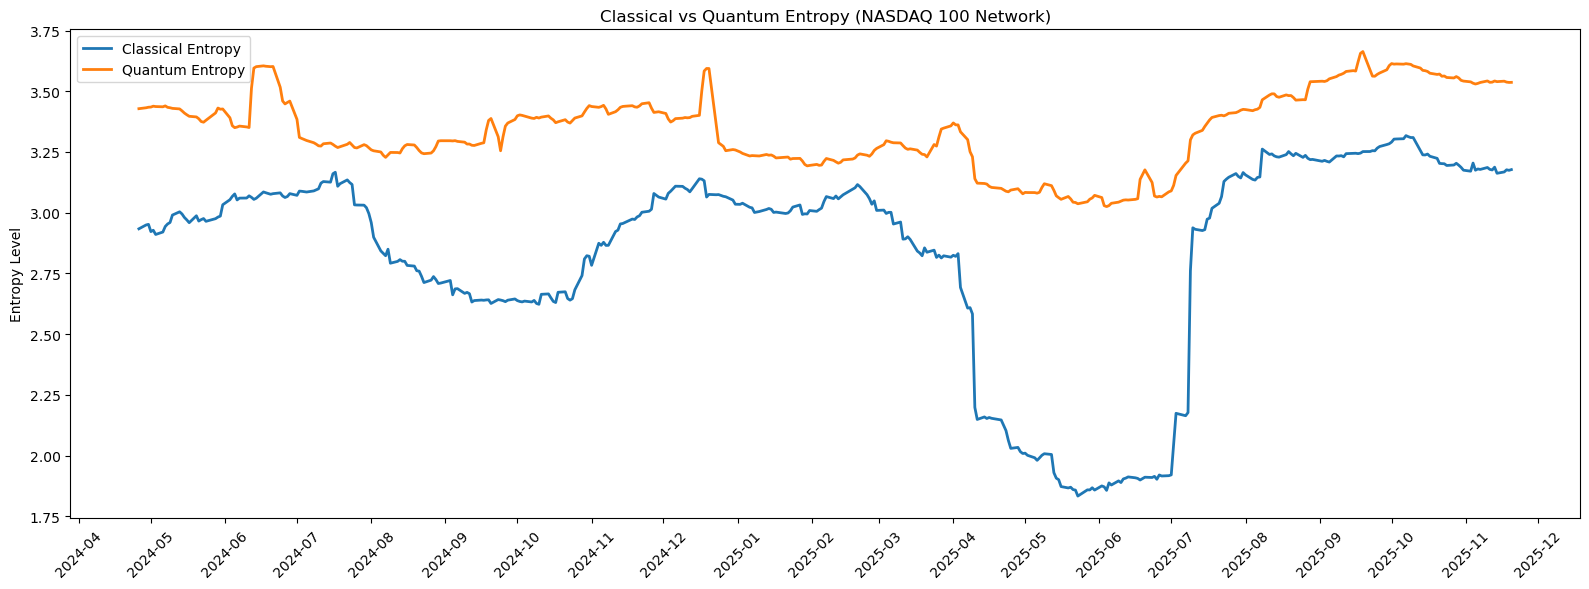

[INFO] QEWS–Index figure saved to: qews_vs_index_2025_trump_tariff.png


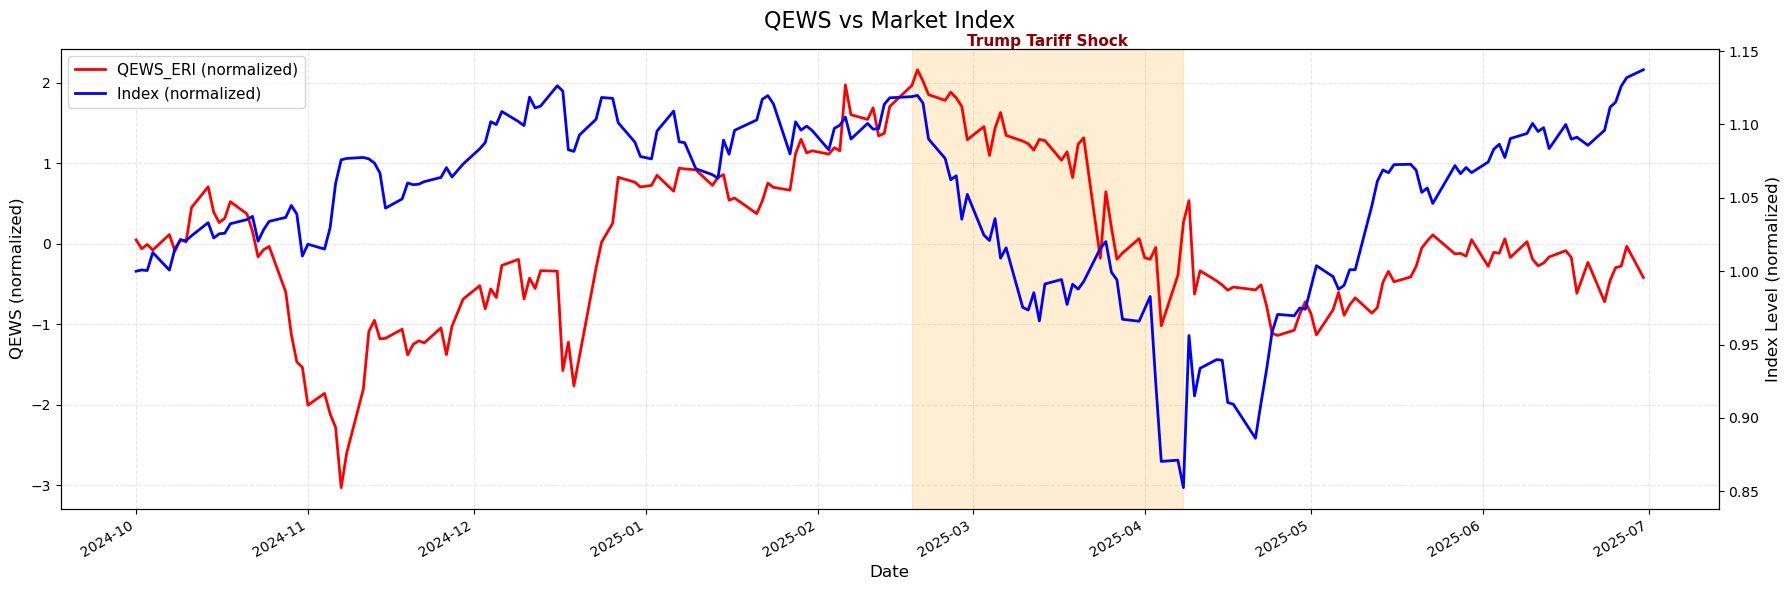

=== NASDAQ 100: Classical vs Quantum Network Metrics ===
INFO_mean_S_classical                        :  2.8141
INFO_mean_S_quantum                          :  3.3253
PRED_corr_classical_index_realized_vol       :  0.5930
PRED_corr_quantum_index_realized_vol         :  0.5235
PRED_corr_classical_index_future_dd          : -0.2886
PRED_corr_quantum_index_future_dd            : -0.1244
STAB_acf1_classical_index                    :  0.9942
STAB_acf1_quantum_index                      :  0.9871
STAB_std_classical_index                     :  0.1070
STAB_std_quantum_index                       :  0.0339
RISK_mean_classical_index_high               :  0.2213
RISK_mean_classical_index_low                :  0.3201
RISK_mean_quantum_index_high                 :  0.0041
RISK_mean_quantum_index_low                  :  0.0389
RISK_jump_classical_index                    : -0.0988
RISK_jump_quantum_index                      : -0.0349


In [14]:
"""
PART 2 — Compute Classical vs Quantum Entropy, ERI and QEWS
Loads ALL DATA FROM CSV (no download)

Make sure you have run PART 1 first.
"""

# import all previously defined functions:
# - build_feature_panel_multi
# - compute_classical_quantum_indices_multi
# - build_index_risk_proxies
# - build_qews
# - compute_early_warning_metrics
# - plot_entropy_series
# - plot_qews_vs_index

# (I will not repeat the function definitions to save space —
#  you already have them exactly as written above.)


# ===== 1. Load tickers =====
def load_tickers_from_excel(path="NASDAQ 100.xlsx"):
    df = pd.read_excel(path, header=None)
    tickers = df[1].astype(str).str.strip().unique().tolist()
    return [t for t in tickers if t.isalpha()]


# ===== 2. Load stock CSV files =====
def load_local_stock_panel(data_dir: str, tickers: list, start_date: str, end_date: str):
    panel = {}
    data_dir = Path(data_dir)

    for t in tickers:
        f = data_dir / f"{t}_{start_date}_{end_date}_daily.csv"
        if f.exists():
            df = pd.read_csv(f, index_col=0, parse_dates=True)
            panel[t] = df
        else:
            print(f"[WARN] Missing {t} CSV file; skipping.")
    return panel


# ===== 3. Load ^IXIC CSV =====
def load_index_csv(data_dir: str, index_ticker: str, start_date: str, end_date: str):
    f = Path(data_dir) / f"{index_ticker}_{start_date}_{end_date}_daily.csv"
    return pd.read_csv(f, index_col=0, parse_dates=True)


# ===== MAIN =====
if __name__ == "__main__":
    data_dir = "data_nasdaq100_2024_2025/"
    index_ticker = "^IXIC"
    start_date = "2024-01-01"
    end_date = "2025-11-21"

    # --- Step 1: Load tickers ---
    tickers = load_tickers_from_excel("NASDAQ 100.xlsx")
    print(f"Loaded {len(tickers)} tickers from Excel")

    # --- Step 2: Load stock panel from CSV ---
    data_dict = load_local_stock_panel(
        data_dir=data_dir,
        tickers=tickers,
        start_date=start_date,
        end_date=end_date
    )
    tickers = sorted(list(data_dict.keys()))
    print(f"Valid tickers found locally: {len(tickers)}")

    # --- Step 3: Load index data ---
    index_df = load_index_csv(data_dir, index_ticker, start_date, end_date)

    # --- Step 4: Build features ---
    features_df = build_feature_panel_multi(data_dict=data_dict, vol_window=20)

    # --- Step 5: Compute classical/quantum entropy & ERI ---
    index_df_multi = compute_classical_quantum_indices_multi(
        features_df=features_df,
        tickers=tickers,
        window=60,
        max_pairs=2000,
        random_seed=42
    )

    # --- Step 6: Build 30-day index risk proxies ---
    index_risk_df = build_index_risk_proxies(index_df=index_df, future_window=30)

    # --- Step 7: Build QEWS ---
    qews_df = build_qews(index_df_multi)

    # --- Step 8: Compute early-warning metrics ---
    ew_df = compute_early_warning_metrics(qews_df=qews_df, risk_df=index_risk_df, max_lag=60)

    print("\n=== TOP lags (best early-warning) ===")
    print(
        ew_df.reindex(
            ew_df["corr_QEWS_Ent_future_dd"].abs().sort_values(ascending=False).index
        ).head(10)
    )

    # --- Step 9: Plot entropy time series ---
    plot_entropy_series(index_df_multi, save_path="entropy_series.png")

    # --- Step 10: Plot QEWS vs index around 2025 Trump Tariff shock ---
    plot_qews_vs_index(
        qews_df=qews_df,
        index_df=index_df,
        start="2024-10-01",   
        end="2025-06-30",     
        event_windows=[
            ("2025-02-18", "2025-04-08", "Trump Tariff Shock"),
        ],
        save_path="qews_vs_index_2025_trump_tariff.png",
    )

     # --- Step 11: Classical vs Quantum Network Metrics (summary) ---
metrics_series = compute_network_summary_metrics(index_df_multi, index_risk_df)

print("=== NASDAQ 100: Classical vs Quantum Network Metrics ===")
for k, v in metrics_series.items():
    print(f"{k:45s}: {v: .4f}")